# Customer Analytics — Exploratory Data Analysis

**Project:** DevelopersHub Customer Analytics
**Objective:** Explore a synthetic customer dataset (10,500 records) covering demographics, purchase history, and engagement metrics, in order to understand churn drivers and prepare the data for classification modeling.

This notebook covers:
1. Data loading & structure overview
2. Data quality checks (missing values, duplicates, outliers)
3. Univariate analysis (distributions of individual features)
4. Bivariate analysis (feature relationships with churn)
5. Correlation analysis
6. Key findings summary

> **Note on the data:** This dataset is synthetically generated (see `src/generate_data.py`) to resemble realistic customer behavior for portfolio/demonstration purposes. It is not real customer data.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (9, 5)

PALETTE = {'primary': '#2E5EAA', 'secondary': '#E8734A', 'success': '#2FA37C', 'neutral': '#6B7280'}
CHURN_COLORS = {0: PALETTE['primary'], 1: PALETTE['secondary']}

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


## 1. Data Loading & Structure Overview

In [2]:
df = pd.read_csv('../data/customer_data.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 10,500 rows x 20 columns


,customer_id,age,gender,region,annual_income,tenure_months,subscription_tier,num_purchases_last_year,avg_order_value,total_spent_last_year,days_since_last_purchase,returns_last_year,email_open_rate,app_sessions_last_month,avg_session_duration_min,support_tickets_last_year,loyalty_points,referral_count,marketing_opt_in,churned
0,100000,43,Female,South,51700.0,22,Basic,0,22.48,0.00,6,0,0.462,1,3.10,1,0,0,1,1
1,100001,25,Female,West,17200.0,11,Basic,9,86.84,781.56,12,0,0.079,7,7.50,0,178,0,0,0
2,100002,49,Female,South,47900.0,12,Premium,9,116.38,1047.42,82,0,0.330,5,5.46,1,763,0,1,1
3,100003,51,Female,East,58600.0,12,Premium,11,86.25,948.75,72,0,0.502,3,8.76,2,476,0,1,0
4,100004,18,Male,West,24300.0,18,Standard,6,70.08,420.48,18,0,0.417,1,21.41,2,478,0,1,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                10500 non-null  int64  
 1   age                        10500 non-null  int64  
 2   gender                     10500 non-null  str    
 3   region                     10500 non-null  str    
 4   annual_income              10165 non-null  float64
 5   tenure_months              10500 non-null  int64  
 6   subscription_tier          10500 non-null  str    
 7   num_purchases_last_year    10500 non-null  int64  
 8   avg_order_value            10500 non-null  float64
 9   total_spent_last_year      10500 non-null  float64
 10  days_since_last_purchase   10500 non-null  int64  
 11  returns_last_year          10500 non-null  int64  
 12  email_open_rate            10289 non-null  float64
 13  app_sessions_last_month    10500 non-null  int64  
 14  a

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
customer_id,10500.0,105249.500000,3031.233247,100000.000,102624.7500,105249.500,107874.2500,110499.000
age,10500.0,39.158667,12.430386,18.000,30.0000,39.000,47.0000,80.000
annual_income,10165.0,48205.991146,17803.134397,15000.000,35500.0000,48000.000,60000.0000,127000.000
tenure_months,10500.0,30.412286,20.299252,1.000,15.0000,26.000,41.0000,120.000
num_purchases_last_year,10500.0,6.776952,3.173037,0.000,5.0000,6.000,9.0000,21.000
avg_order_value,10500.0,53.616696,39.739668,5.000,25.7375,43.595,70.2850,381.390
total_spent_last_year,10500.0,399.045281,446.937831,0.000,129.3200,256.440,495.4075,5747.680
days_since_last_purchase,10500.0,44.387524,43.972387,0.000,13.0000,31.000,62.0000,433.000
returns_last_year,10500.0,0.400190,0.650481,0.000,0.0000,0.000,1.0000,5.000
email_open_rate,10289.0,0.408323,0.192207,0.007,0.2590,0.397,0.5480,0.968


## 2. Data Quality Checks

Before analyzing patterns, we check for missing values, duplicates, and obviously invalid values — standard first steps for any real-world dataset.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
annual_income,335,3.19
email_open_rate,211,2.01
avg_session_duration_min,149,1.42


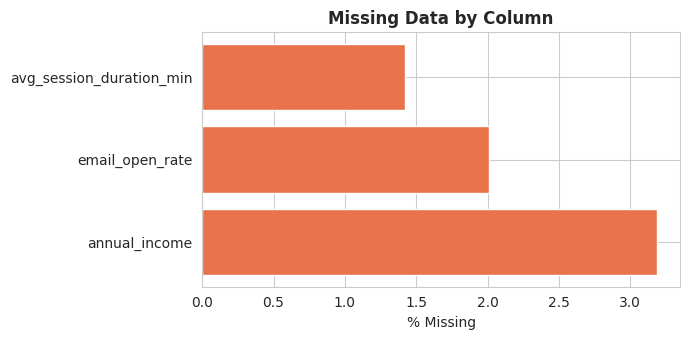

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
if len(missing_summary) > 0:
    ax.barh(missing_summary.index, missing_summary['missing_pct'], color=PALETTE['secondary'])
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Data by Column', weight='bold')
plt.tight_layout()
plt.show()


In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customer IDs: {df['customer_id'].duplicated().sum()}")


Duplicate rows: 0
Duplicate customer IDs: 0


In [8]:
# Sanity-check value ranges for a few key numeric columns
sanity_cols = ['age', 'annual_income', 'tenure_months', 'email_open_rate', 'num_purchases_last_year']
df[sanity_cols].describe().loc[['min', 'max']]


,age,annual_income,tenure_months,email_open_rate,num_purchases_last_year
min,18.0,15000.0,1.0,0.007,0.0
max,80.0,127000.0,120.0,0.968,21.0


**Findings:** A small amount of missingness (1.5-3.2%) was injected into `annual_income`, `email_open_rate`, and `avg_session_duration_min` to simulate realistic data collection gaps. No duplicate customer IDs. All value ranges look plausible (ages 18-80, income $15k-$220k, open rates 0-1).

## 3. Target Variable: Churn Distribution

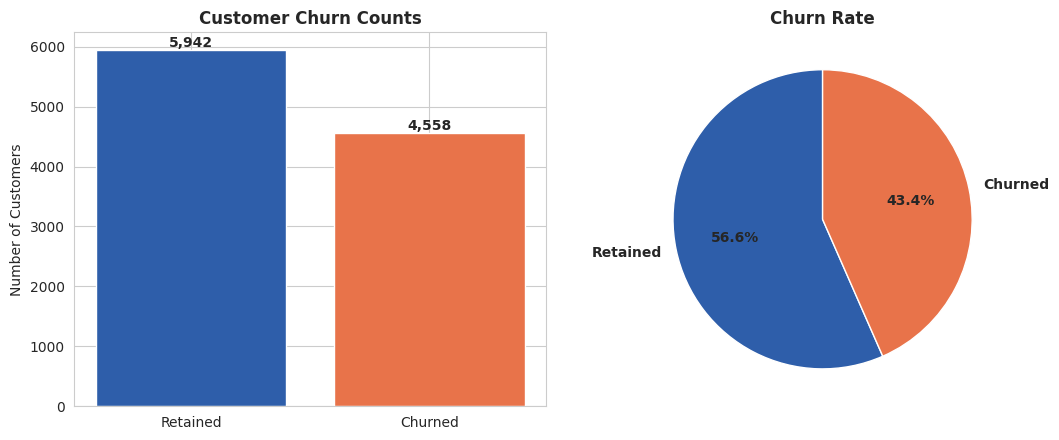

Overall churn rate: 43.41%


In [9]:
churn_counts = df['churned'].value_counts()
churn_rate = df['churned'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(['Retained', 'Churned'], churn_counts.reindex([0, 1]).values,
            color=[PALETTE['primary'], PALETTE['secondary']])
axes[0].set_title('Customer Churn Counts', weight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.reindex([0, 1]).values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.reindex([0, 1]).values, labels=['Retained', 'Churned'],
            colors=[PALETTE['primary'], PALETTE['secondary']], autopct='%1.1f%%',
            startangle=90, textprops={'fontweight': 'bold'})
axes[1].set_title('Churn Rate', weight='bold')

plt.tight_layout()
plt.show()
print(f"Overall churn rate: {churn_rate:.2%}")


**Finding:** Churn is fairly balanced (~43% churned vs ~57% retained), which is common in subscription/churn-risk business contexts where the analysis specifically targets an at-risk segment. This balance also means accuracy is a meaningful metric here (unlike highly imbalanced fraud-style problems where accuracy alone would be misleading).

## 4. Univariate Analysis — Demographics

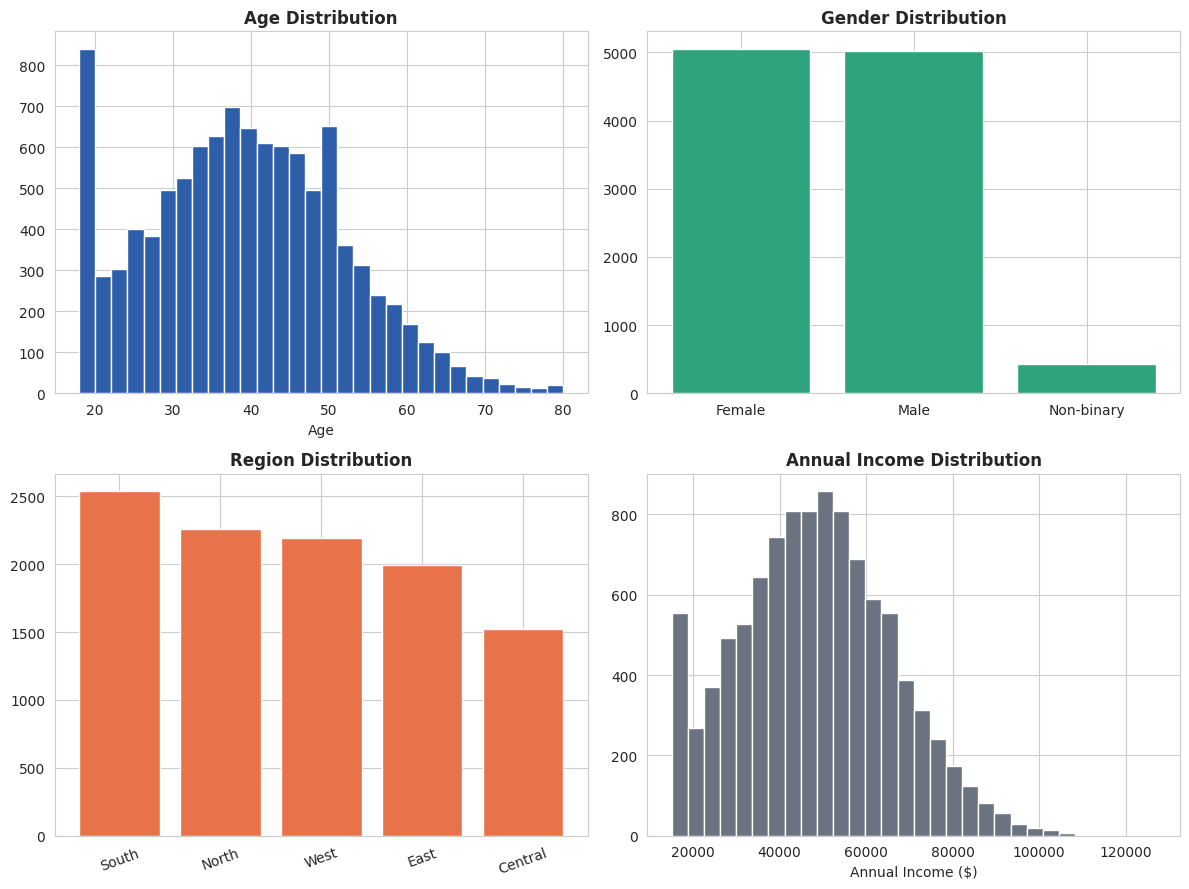

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df['age'], bins=30, color=PALETTE['primary'], edgecolor='white')
axes[0, 0].set_title('Age Distribution', weight='bold')
axes[0, 0].set_xlabel('Age')

gender_counts = df['gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=PALETTE['success'])
axes[0, 1].set_title('Gender Distribution', weight='bold')

region_counts = df['region'].value_counts()
axes[1, 0].bar(region_counts.index, region_counts.values, color=PALETTE['secondary'])
axes[1, 0].set_title('Region Distribution', weight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)

axes[1, 1].hist(df['annual_income'].dropna(), bins=30, color=PALETTE['neutral'], edgecolor='white')
axes[1, 1].set_title('Annual Income Distribution', weight='bold')
axes[1, 1].set_xlabel('Annual Income ($)')

plt.tight_layout()
plt.show()


**Findings:** Age is roughly normally distributed around ~39 years (range 18-80). Gender split is close to even between Female/Male with a small Non-binary segment. Regions are fairly evenly represented (15-24% each). Annual income is right-skewed, as is typical for income data, centered around $45-50k.

## 5. Univariate Analysis — Purchase & Engagement Behavior

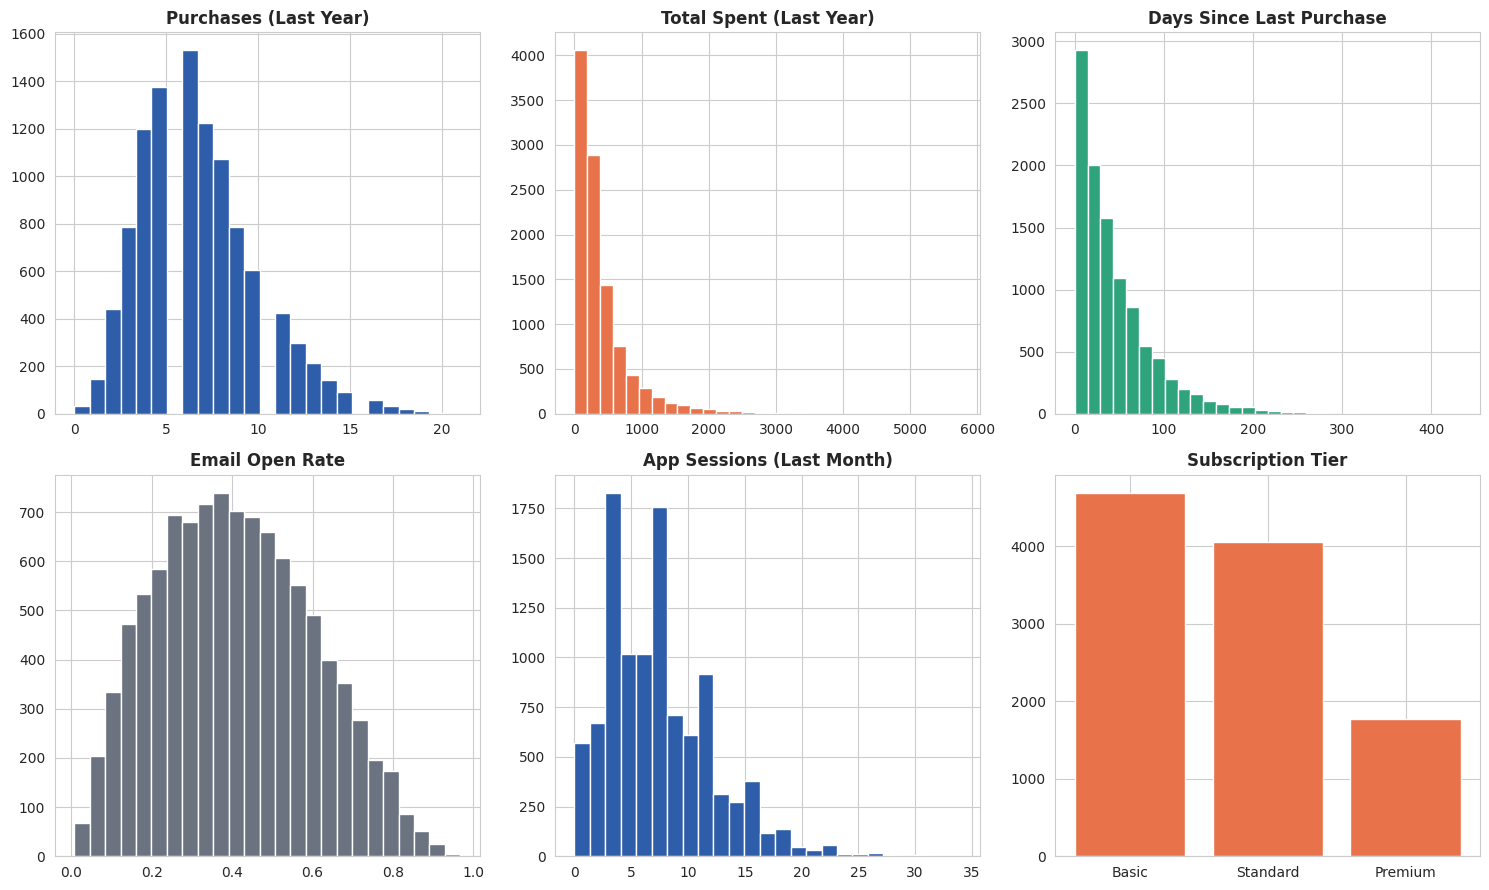

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].hist(df['num_purchases_last_year'], bins=25, color=PALETTE['primary'], edgecolor='white')
axes[0, 0].set_title('Purchases (Last Year)', weight='bold')

axes[0, 1].hist(df['total_spent_last_year'], bins=30, color=PALETTE['secondary'], edgecolor='white')
axes[0, 1].set_title('Total Spent (Last Year)', weight='bold')

axes[0, 2].hist(df['days_since_last_purchase'], bins=30, color=PALETTE['success'], edgecolor='white')
axes[0, 2].set_title('Days Since Last Purchase', weight='bold')

axes[1, 0].hist(df['email_open_rate'].dropna(), bins=25, color=PALETTE['neutral'], edgecolor='white')
axes[1, 0].set_title('Email Open Rate', weight='bold')

axes[1, 1].hist(df['app_sessions_last_month'], bins=25, color=PALETTE['primary'], edgecolor='white')
axes[1, 1].set_title('App Sessions (Last Month)', weight='bold')

tier_counts = df['subscription_tier'].value_counts()
axes[1, 2].bar(tier_counts.index, tier_counts.values, color=PALETTE['secondary'])
axes[1, 2].set_title('Subscription Tier', weight='bold')

plt.tight_layout()
plt.show()


**Findings:** Purchase counts and total spend are right-skewed (a long tail of high-value customers), typical of real purchase data. Days since last purchase shows an exponential-like decay — most customers purchased recently, with a long tail of lapsed customers. Subscription tiers skew toward Basic/Standard, with Premium as a smaller ~17% segment.

## 6. Bivariate Analysis — Features vs. Churn

/tmp/ipykernel_637/2885305695.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_637/2885305695.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_637/2885305695.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_637/2885305695.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Retained', 'Churned'])


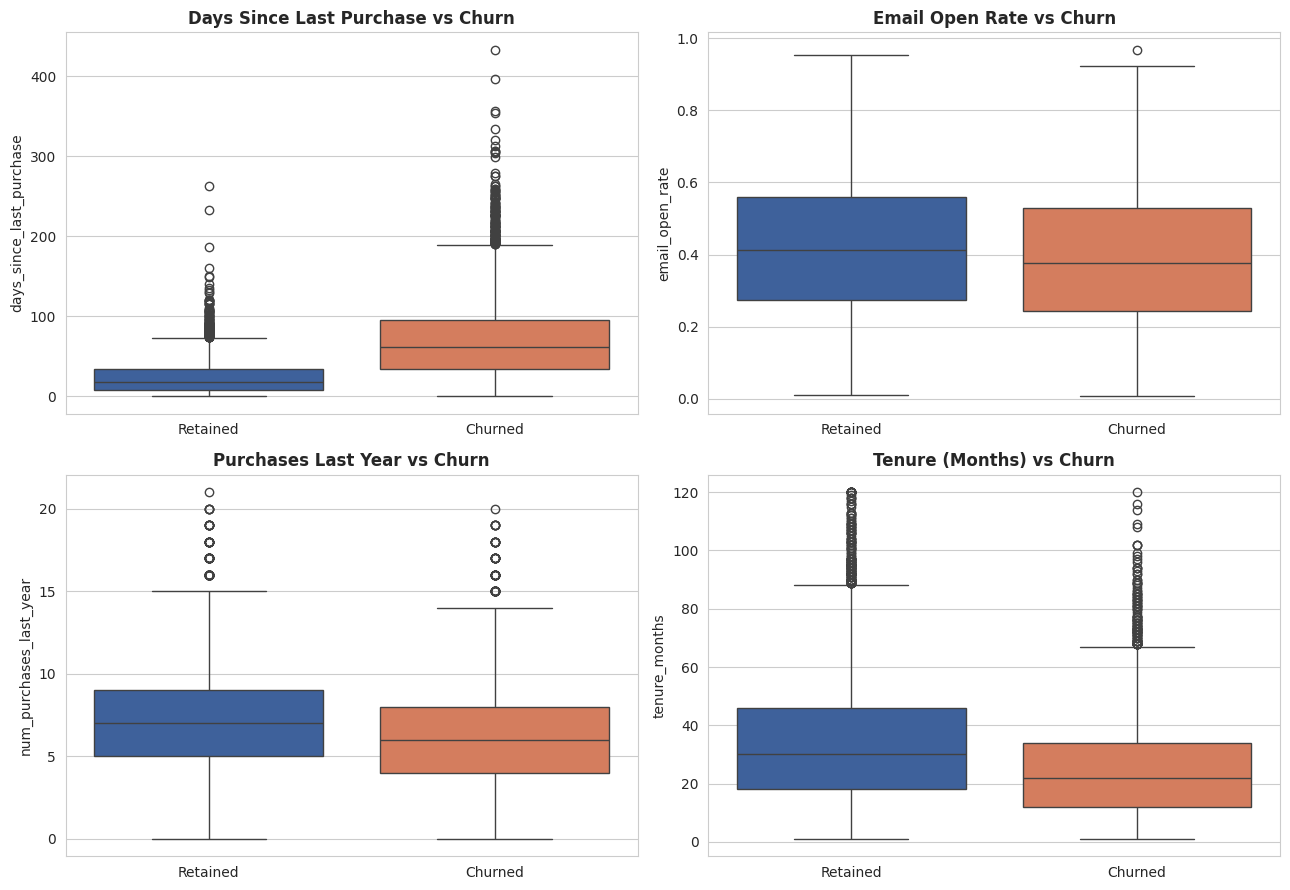

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=df, x='churned', y='days_since_last_purchase', hue='churned',
            palette=CHURN_COLORS, ax=axes[0, 0], legend=False)
axes[0, 0].set_xticklabels(['Retained', 'Churned'])
axes[0, 0].set_title('Days Since Last Purchase vs Churn', weight='bold')
axes[0, 0].set_xlabel('')

sns.boxplot(data=df, x='churned', y='email_open_rate', hue='churned',
            palette=CHURN_COLORS, ax=axes[0, 1], legend=False)
axes[0, 1].set_xticklabels(['Retained', 'Churned'])
axes[0, 1].set_title('Email Open Rate vs Churn', weight='bold')
axes[0, 1].set_xlabel('')

sns.boxplot(data=df, x='churned', y='num_purchases_last_year', hue='churned',
            palette=CHURN_COLORS, ax=axes[1, 0], legend=False)
axes[1, 0].set_xticklabels(['Retained', 'Churned'])
axes[1, 0].set_title('Purchases Last Year vs Churn', weight='bold')
axes[1, 0].set_xlabel('')

sns.boxplot(data=df, x='churned', y='tenure_months', hue='churned',
            palette=CHURN_COLORS, ax=axes[1, 1], legend=False)
axes[1, 1].set_xticklabels(['Retained', 'Churned'])
axes[1, 1].set_title('Tenure (Months) vs Churn', weight='bold')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()


**Finding:** Churned customers show clearly higher `days_since_last_purchase` (recency gap) and lower `email_open_rate` / `num_purchases_last_year` — consistent with disengagement preceding churn. Tenure shows a milder relationship.

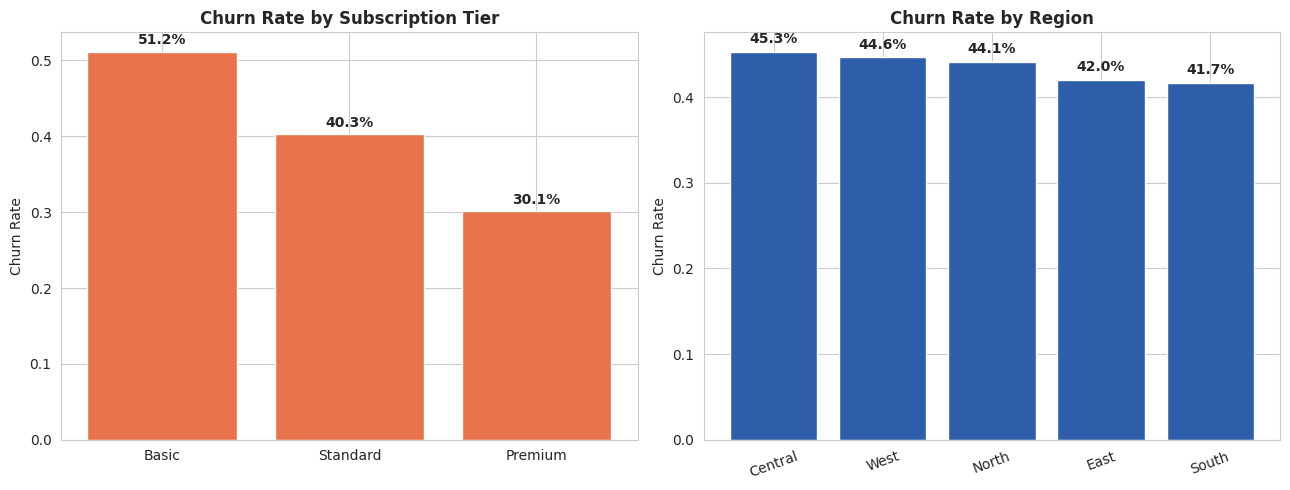

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tier_churn = df.groupby('subscription_tier')['churned'].mean().sort_values(ascending=False)
axes[0].bar(tier_churn.index, tier_churn.values, color=PALETTE['secondary'])
axes[0].set_title('Churn Rate by Subscription Tier', weight='bold')
axes[0].set_ylabel('Churn Rate')
for i, v in enumerate(tier_churn.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

region_churn = df.groupby('region')['churned'].mean().sort_values(ascending=False)
axes[1].bar(region_churn.index, region_churn.values, color=PALETTE['primary'])
axes[1].set_title('Churn Rate by Region', weight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(region_churn.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Finding:** Basic-tier customers churn noticeably more than Premium — consistent with the intuition that higher-commitment customers are more invested. Regional differences are modest, suggesting region is a weaker standalone churn predictor.

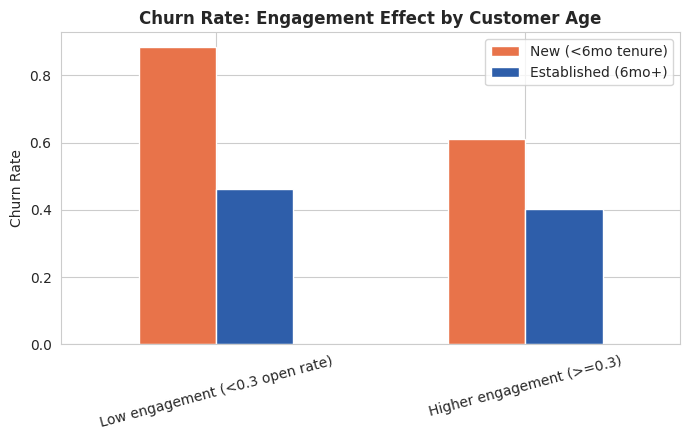

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
new_customers = df[df['tenure_months'] < 6]
established = df[df['tenure_months'] >= 6]

comparison = pd.DataFrame({
    'New (<6mo tenure)': [new_customers[new_customers['email_open_rate'] < 0.3]['churned'].mean(),
                          new_customers[new_customers['email_open_rate'] >= 0.3]['churned'].mean()],
    'Established (6mo+)': [established[established['email_open_rate'] < 0.3]['churned'].mean(),
                           established[established['email_open_rate'] >= 0.3]['churned'].mean()],
}, index=['Low engagement (<0.3 open rate)', 'Higher engagement (>=0.3)'])

comparison.plot(kind='bar', ax=ax, color=[PALETTE['secondary'], PALETTE['primary']])
ax.set_title('Churn Rate: Engagement Effect by Customer Age', weight='bold')
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='')
plt.tight_layout()
plt.show()


**Finding:** Low engagement is associated with a much larger churn-rate gap for new customers than for established ones — an early \"honeymoon risk window\" where disengagement signals are especially predictive. This kind of interaction effect is part of why tree-based models (Random Forest, XGBoost) tend to outperform plain logistic regression on this data — see the modeling notebook/scripts.

## 7. Correlation Analysis

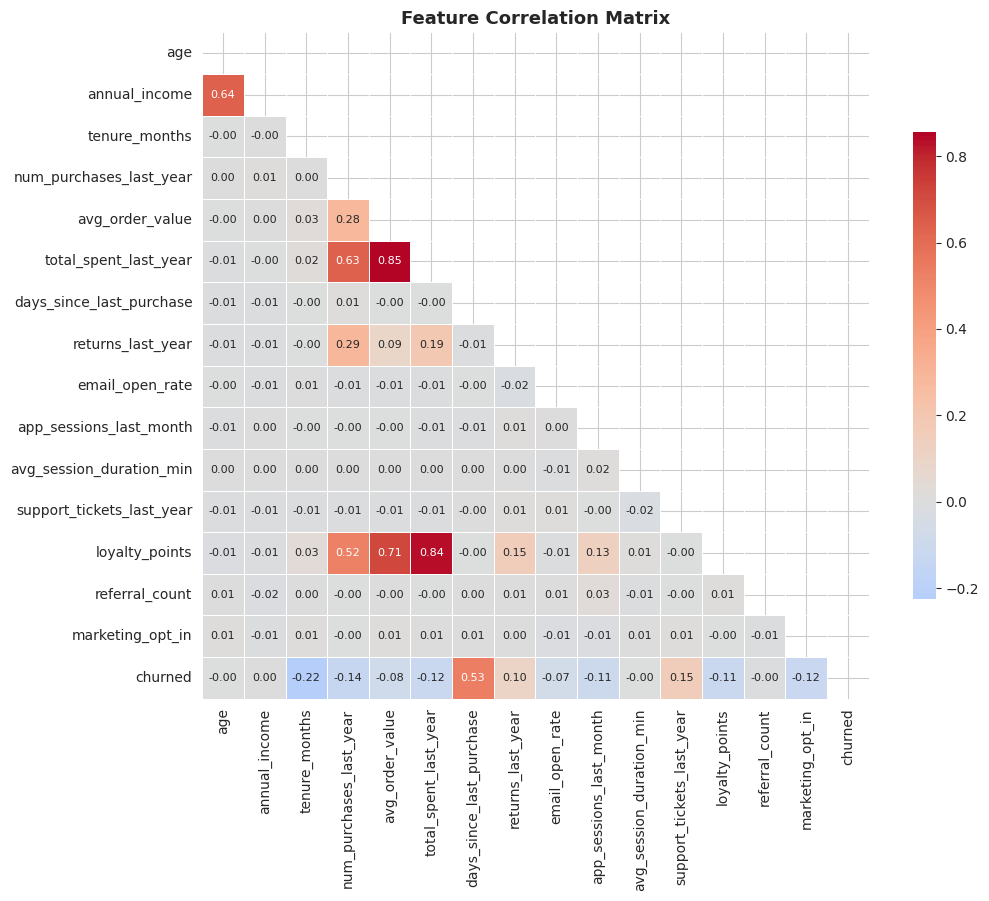

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['customer_id'])
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
churn_corr = corr_matrix['churned'].drop('churned').sort_values(key=abs, ascending=False)
print("Features most correlated with churn:")
churn_corr.head(10)


Features most correlated with churn:


days_since_last_purchase     0.530628
tenure_months               -0.223978
support_tickets_last_year    0.153756
num_purchases_last_year     -0.138403
marketing_opt_in            -0.119000
total_spent_last_year       -0.118295
loyalty_points              -0.113877
app_sessions_last_month     -0.105504
returns_last_year            0.101603
avg_order_value             -0.082591
Name: churned, dtype: float64

**Finding:** `days_since_last_purchase` shows the strongest linear correlation with churn, followed by engagement metrics (`email_open_rate`, `app_sessions_last_month`) and purchase frequency. No pair of independent features shows extreme multicollinearity (|r| > 0.9), so no features need to be dropped before modeling.

## 8. Key Findings Summary

Based on this EDA, the strongest churn signals are:

1. **Recency** — `days_since_last_purchase` is the single strongest predictor; lapsed customers are at high churn risk.
2. **Engagement** — low `email_open_rate` and low `app_sessions_last_month` both correlate with churn, and this effect is *stronger for new customers* (tenure < 6 months) than for established ones.
3. **Subscription tier** — Basic-tier customers churn at a meaningfully higher rate than Premium.
4. **Returns & support tickets** — customers with returns or support tickets churn more, especially when combined with low overall purchase activity (an interaction effect, not just a main effect).
5. **Region and gender** show comparatively weak standalone relationships with churn.

These findings motivate the modeling approach in `notebooks/model_training_evaluation.ipynb` and `src/train_model.py`: because several of the strongest relationships are *interactions* rather than simple linear effects, tree-based ensemble methods (Random Forest, XGBoost) are expected to — and do — outperform plain logistic regression, with **XGBoost achieving ~86% test accuracy**, the best of the three models compared.
